## I-JEPA Forward Pass

Load an image, mask it, run the encoder + predictor, compute the loss

In [1]:
import equinox as eqx
import jax
import matplotlib.pyplot as plt
from jax import numpy as jnp
from jepax.data import build_torch_dataloader
from jepax.model.ijepa import get_ijepa_model
from jepax.model.masker import IJEPAMasker, visualize_mask

In [2]:
PATCH_SIZE = 2
IMG_SIZE = 32
N_PATCH = IMG_SIZE // PATCH_SIZE  # 16
M = 4  # number of prediction masks

key = jax.random.PRNGKey(42)

## 1. Load data & visualize masks

Load a single data point. Visualize the encoder mask by constructing it with context and predictor mask from the masker.
- `mask_ctx` is a `(n_patch**2,)` boolean array
- `mask_pred` is a  `(M, n_patch**2)` boolean array, where `M` is the number of predictor masks


In [3]:
dataloader, _, _, _ = build_torch_dataloader("CIFAR10", data_dir="~/data")

/Users/anton/source/jepax/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


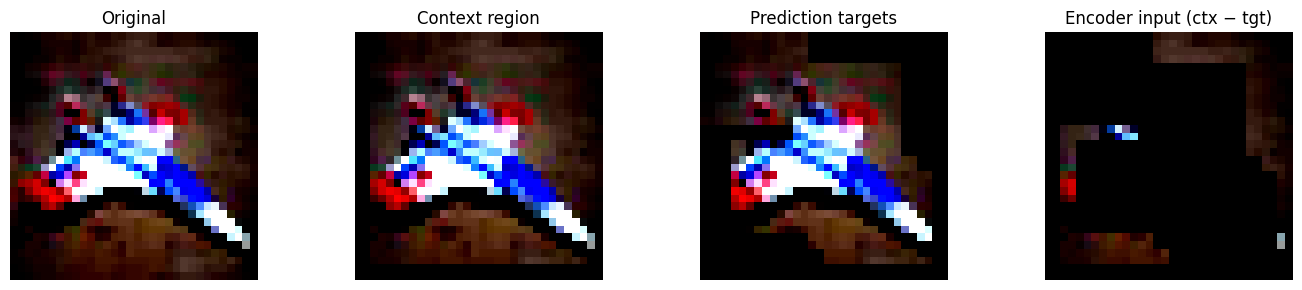

In [4]:
x, y = next(iter(dataloader))
x_in = x[-2]

masker = IJEPAMasker(
    IMG_SIZE,
    IMG_SIZE,
    PATCH_SIZE,
    ctx_scale=0.85,
    pred_scale=(0.15, 0.2),
    pred_aspect=(0.75, 1.2),
)

key, key_mask = jax.random.split(key)
mask_ctx, mask_pred = masker(key_mask, M, flatten=True)

# what the encoder sees
mask_pred_union = jnp.any(mask_pred, axis=0)
mask_enc = mask_ctx & ~mask_pred_union

show = lambda img, mask: visualize_mask(img, mask, PATCH_SIZE, N_PATCH)

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
axes[0].imshow(x_in)
axes[0].set_title("Original")
axes[1].imshow(show(x_in, mask_ctx))
axes[1].set_title("Context region")
axes[2].imshow(show(x_in, mask_pred_union))
axes[2].set_title("Prediction targets")
axes[3].imshow(show(x_in, mask_enc))
axes[3].set_title("Encoder input (ctx − tgt)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Build model & forward pass

Initialize a tiny IJEPA model and do a single forward pass using the above masks. 

In [5]:
x_in = jnp.transpose(x[0], (2, 0, 1))

In [6]:
key, key_model = jax.random.split(key)

model, embed_dim = get_ijepa_model(
    "ijepa-test",
    key=key_model,
    num_channels=3,
    patch_size=PATCH_SIZE,
    img_size=IMG_SIZE,
    p_drop=0.0,
)

print(f"Embed dim: {embed_dim}")
print(f"Encoder blocks: {len(model.encoder.transformer.blocks)}")
print(f"Predictor blocks: {len(model.predictor.transformer.blocks)}")
n_params = sum(x.size for x in jax.tree.leaves(eqx.filter(model, eqx.is_array)))
print(f"Total params: {n_params:,}")

/Users/anton/source/jepax/jepax/model/ijepa.py:250: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  self.pe = PositionalEncoding2D(dim=dim, seq_len=seq_len, grid_size=grid_size)


Embed dim: 64
Encoder blocks: 2
Predictor blocks: 2
Total params: 126,016


/Users/anton/source/jepax/jepax/model/ijepa.py:342: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  self.pe = PositionalEncoding2D(


In [7]:
# Forward pass through the full model
key, key_fwd = jax.random.split(key)

z_pred, tgt_indices, n_tgt, pred_start, pred_end = model(
    key_fwd, x_in, mask_ctx, mask_pred, train=False
)

print(f"z_pred: {z_pred.shape} (seq_len, D)")
print(f"n_tgt: {n_tgt}")

z_pred: (256, 64) (seq_len, D)
n_tgt: 163


## 3. Compute I-JEPA loss

Though the paper uses $L_2$ loss among target patches, training involves the `torch` smooth $L_1$ loss, defined component-wise as
$$
\ell_\beta(x_i) = \begin{cases}\dfrac{(x)^2}{2\beta} ,& |x| < \beta \\ |x| - \dfrac{\beta}{2} ,& |x| \geq \beta\end{cases}
$$
That is, the gradient at each parameter is clipped to $\pm 1$.
More on this in the blog...

In [9]:
# EMA target: encode full image
key, key_ema = jax.random.split(key)
ema_encoder = model.encoder  # typically the ema copy

z_ema, _ = eqx.nn.inference_mode(ema_encoder)(key_ema, x_in, mask=None, train=False)
print(f"z_ema (full image): {z_ema.shape}")  # (N_patches, D)

# Optional: normalize targets
mean = jnp.mean(z_ema, axis=-1, keepdims=True)
var = jnp.var(z_ema, axis=-1, keepdims=True)
z_ema = (z_ema - mean) / jnp.sqrt(var + 1e-6)

z_ema (full image): (256, 64)


Isolate indices informed by the pred masks and apply the above $\ell_\beta$ loss.

In [10]:
# Extract target representations at predicted positions
z_tgt = z_ema[tgt_indices]  # (seq_len, D)

# Shift predictor output to align: predictions sit at [pred_start:pred_end]
z_pred_shifted = jnp.roll(z_pred, -pred_start, axis=0)

# Valid mask: only the first n_tgt positions matter
valid = jnp.arange(z_pred.shape[0]) < n_tgt

# Smooth L1 loss
diff = z_pred_shifted - z_tgt
abs_diff = jnp.abs(diff)
smooth_l1 = jnp.where(abs_diff < 1.0, 0.5 * diff**2, abs_diff - 0.5)

loss_per_token = jnp.mean(smooth_l1, axis=-1)  # (seq_len,)
loss = jnp.sum(loss_per_token * valid) / jnp.sum(valid)

print(f"Smooth L1 loss: {loss:.4f}")
print(f"Valid target tokens: {int(jnp.sum(valid))} / {z_pred.shape[0]}")

Smooth L1 loss: 0.5722
Valid target tokens: 163 / 256
